# Spatial interaction scoring with Squidpy

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)  

In [1]:
from pathlib import Path
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata
import scanpy as sc
import squidpy as sq

from sklearn.preprocessing import MinMaxScaler

import pickle

import matplotlib as mpl
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['pdf.fonttype'] = 42

warnings.simplefilter(action='ignore', category=Warning)

## Local file info

In [2]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
structures_dir = os.path.join(BASE_OUTDIR, "structures")
out_dir = os.path.join(BASE_OUTDIR, "downstream_analysis")

plot_out_dir = os.path.join(out_dir, 'plots')
if not os.path.exists(plot_out_dir):
    os.makedirs(plot_out_dir)

print(out_dir)

/home/workspace/spatial_mouse_lung_outputs/downstream_analysis


In [3]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

## Load adata

In [4]:
adata = sc.read_h5ad(os.path.join(structures_dir,'adata_labeled_zones_structures.h5ad'))

## Load palettes

In [5]:
with open(os.path.join(inputs_dir, 'palettes/20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250521_zone_consol_palette_mapped.pkl'), 'rb') as f:
    zone_consol_palette_mapped = pickle.load(f)

# Zone comparisons 

## Interaction score zone comparison 

In [6]:
# Run this analysis on adata_HDM the 3 zones of interest
# Make a new label column that is same as label_fine, but all activated CD4s are grouped
adata_int = adata[adata.obs['sample_label'] == 'HDM_day3', :].copy()

In [7]:
adata_int.obs['label_for_int'] = adata_int.obs['label_fine'].copy()
adata_int.obs['label_for_int'] = adata_int.obs['label_for_int'].replace('Th0', 'CD4 act')
adata_int.obs['label_for_int'] = adata_int.obs['label_for_int'].replace('Th1', 'CD4 act')
adata_int.obs['label_for_int'] = adata_int.obs['label_for_int'].replace('Th17', 'CD4 act')
adata_int.obs['label_for_int'] = adata_int.obs['label_for_int'].replace('Th2', 'CD4 act')
adata_int.obs['label_for_int'] = adata_int.obs['label_for_int'].replace('Treg', 'CD4 act')
adata_int.obs['label_for_int'] = adata_int.obs['label_for_int'].replace('CD4 trans', 'CD4 act')

In [8]:
adata_int_TLS = adata_int[adata_int.obs['zone_consol']=='TLS', :]
adata_int_adventitia = adata_int[adata_int.obs['zone_consol']=='adventitia', :]
adata_int_parenchyma = adata_int[adata_int.obs['zone_consol']=='parenchyma', :]
print(adata_int_TLS.shape)
print(adata_int_adventitia.shape)
print(adata_int_parenchyma.shape)

(24076, 480)
(46023, 480)
(251594, 480)


In [9]:
print(adata_int_TLS[adata_int_TLS.obs['label_for_int']=='CD4 act', :].shape)
print(adata_int_adventitia[adata_int_adventitia.obs['label_for_int']=='CD4 act', :].shape)
print(adata_int_parenchyma[adata_int_parenchyma.obs['label_for_int']=='CD4 act', :].shape)

(1200, 480)
(1384, 480)
(5918, 480)


### Run squidpy interaction scoring

In [10]:
for adata_subset in [adata_int_TLS, adata_int_adventitia, adata_int_parenchyma]:
    sq.gr.spatial_neighbors(adata_subset, coord_type="generic", delaunay=True, key_added= 'spatial_new')
    sq.gr.interaction_matrix(adata_subset, cluster_key="label_for_int", connectivity_key = 'spatial_new', 
                                        normalized=True)

### Visualize interaction differences between zones

In [11]:
labels_TLS  = adata_int_TLS.obs['label_for_int'].cat.categories
z_TLS = pd.DataFrame(
    adata_int_TLS.uns['label_for_int_interactions'],
    index=labels_TLS, columns=labels_TLS
)

labels_adventitia  = adata_int_adventitia.obs['label_for_int'].cat.categories
z_adventitia = pd.DataFrame(
    adata_int_adventitia.uns['label_for_int_interactions'],
    index=labels_adventitia, columns=labels_adventitia
)

labels_parenchyma  = adata_int_parenchyma.obs['label_for_int'].cat.categories
z_parenchyma = pd.DataFrame(
    adata_int_parenchyma.uns['label_for_int_interactions'],
    index=labels_parenchyma, columns=labels_parenchyma
)

# confirm all cell types included in each
print(z_TLS.shape)
print(z_adventitia.shape)
print(z_parenchyma.shape)

(32, 32)
(32, 32)
(32, 32)


In [12]:
ordered_cols = z_parenchyma.columns
ordered_cols

Index(['AT1', 'AT2', 'Club', 'Ciliated', 'SMC', 'Col13a1+ fibroblast',
       'Col14a1+ fibroblast', 'Myofibroblast', 'Pericyte 1', 'Pericyte 2',
       'Mesothelial', 'Cap', 'Cap-a', 'Art', 'Vein', 'Lymph', 'Mono', 'Int Mf',
       'Alv Mf', 'Neut', 'cDC1', 'Ccr7- cDC2', 'Ccr7+ cDC2', 'B cell',
       'Plasmablast', 'NK cell', 'gd T cell', 'ILC2', 'CD8 naive', 'CD8 act',
       'CD4 naive', 'CD4 act'],
      dtype='object')

In [13]:
row_TLS = z_TLS.loc['CD4 act'].reindex(ordered_cols)
row_TLS

AT1                    0.011119
AT2                    0.086559
Club                   0.007319
Ciliated               0.002815
SMC                    0.011400
Col13a1+ fibroblast    0.016749
Col14a1+ fibroblast    0.028008
Myofibroblast          0.000141
Pericyte 1             0.008304
Pericyte 2             0.014778
Mesothelial            0.000141
Cap                    0.058128
Cap-a                  0.006756
Art                    0.000704
Vein                   0.003519
Lymph                  0.006756
Mono                   0.003378
Int Mf                 0.053202
Alv Mf                 0.016467
Neut                   0.005208
cDC1                   0.011260
Ccr7- cDC2             0.013934
Ccr7+ cDC2             0.011400
B cell                 0.417452
Plasmablast            0.025194
NK cell                0.002252
gd T cell              0.075440
ILC2                   0.000141
CD8 naive              0.000422
CD8 act                0.015904
CD4 naive              0.006052
CD4 act 

In [14]:
# Use z_TLS.columns as the master column order
ordered_cols = z_parenchyma.columns

# Reindex each row to match the full column set and preserve order
row_TLS = z_TLS.loc['CD4 act'].reindex(ordered_cols)
row_adventitia = z_adventitia.loc['CD4 act'].reindex(ordered_cols)
row_parenchyma = z_parenchyma.loc['CD4 act'].reindex(ordered_cols)

# Stack into a DataFrame
int_summary = pd.DataFrame([row_TLS, row_adventitia, row_parenchyma])
int_summary.index = ['TLS', 'adventitia', 'parenchyma']


In [38]:
print(int_summary.max(axis=1))
print(int_summary.idxmax(axis=1))

TLS           0.417452
adventitia    0.129369
parenchyma    0.177460
dtype: float64
TLS           B cell
adventitia    Int Mf
parenchyma       Cap
dtype: object


Visualize interaction matrix with H2-Ab1 of each neighbor cell types above, to identify which neighbor cell types may acts as APCs to CD4 T cells in each spatial zones.

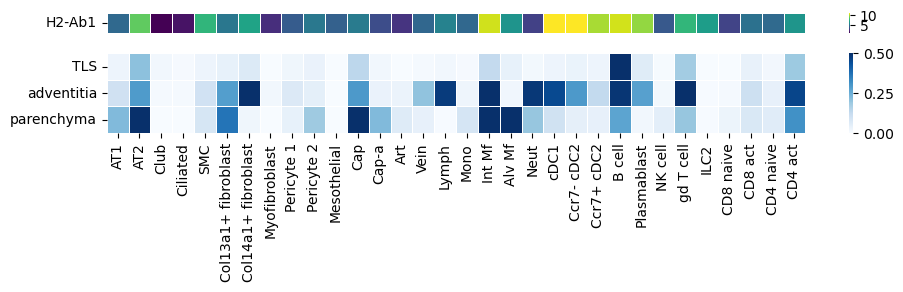

In [41]:
# Scale interaction matrix
scaler = MinMaxScaler()
int_summary_scaled = scaler.fit_transform(int_summary.T).T
xticklabels = list(ordered_cols)
yticklabels_top = ['TLS', 'adventitia', 'parenchyma']

# Extract gene expression data
adata_gene = adata_int[:, ['H2-Ab1']]
gene_expr_df = pd.DataFrame(
    adata_gene.X.toarray() if hasattr(adata_gene.X, "toarray") else adata_gene.X,
    index=adata_gene.obs['label_for_int'],
    columns=adata_gene.var_names
)

# Average per label
gene_matrix = gene_expr_df.groupby(level=0).mean().T.reindex(columns=xticklabels).fillna(0)

# Create stacked heatmap figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), height_ratios=[1,4], sharex=True)

# Top: expression of H2-Ab1
sns.heatmap(
    gene_matrix,
    xticklabels=xticklabels,
    yticklabels=['H2-Ab1'],
    ax=ax1,
    cmap='viridis',
    linecolor="white",
    linewidths=0.5,
)
ax1.set_xlabel('')
ax1.tick_params(axis='x', bottom=False, top=False)
ax1.tick_params(axis='x')
ax1.tick_params(axis='y', rotation=0)

# bottom: interaction scores
sns.heatmap(
    int_summary_scaled,
    xticklabels=xticklabels,
    yticklabels=yticklabels_top,
    ax=ax2,
    cmap='Blues',
    vmax=.5,
    linecolor="white",
    linewidths=0.5
)
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()

fig.savefig(os.path.join(plot_out_dir, "HDM_day3_zone_interactions_CD4act_allcells_vmax_H2Ab1.png"), dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(os.path.join(plot_out_dir, "HDM_day3_zone_interactions_CD4act_allcells_vmax_H2Ab1.pdf"), dpi=300, bbox_inches='tight', transparent=True)

## Save

In [42]:
adata.write_h5ad(os.path.join(out_dir,'adata_distance.h5ad'), compression='gzip')

In [43]:
import session_info
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active conda environment:  space2
